In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# load data 
df = pd.read_csv("List of Orders.csv")
df.head()

,Order ID,Order Date,CustomerName,State,City
0,B-25601,01-04-2018,Bharat,Gujarat,Ahmedabad
1,B-25602,01-04-2018,Pearl,Maharashtra,Pune
2,B-25603,03-04-2018,Jahan,Madhya Pradesh,Bhopal
3,B-25604,03-04-2018,Divsha,Rajasthan,Jaipur
4,B-25605,05-04-2018,Kasheen,West Bengal,Kolkata


In [3]:
# BASIC INFORMATION
df.shape

(560, 5)

In [4]:
df.columns

Index(['Order ID', 'Order Date', 'CustomerName', 'State', 'City'], dtype='str')

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 560 entries, 0 to 559
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   Order ID      500 non-null    str  
 1   Order Date    500 non-null    str  
 2   CustomerName  500 non-null    str  
 3   State         500 non-null    str  
 4   City          500 non-null    str  
dtypes: str(5)
memory usage: 22.0 KB


In [6]:
df.isnull().sum()

Order ID        60
Order Date      60
CustomerName    60
State           60
City            60
dtype: int64

In [7]:
# DATA CLEANING
df = df.dropna(how="all")
df["Order Date"] = pd.to_datetime(df["Order Date"],dayfirst=True,errors="coerce")
df = df.dropna(subset=["Order ID", "Order Date"])
df.head()

,Order ID,Order Date,CustomerName,State,City
0,B-25601,2018-04-01,Bharat,Gujarat,Ahmedabad
1,B-25602,2018-04-01,Pearl,Maharashtra,Pune
2,B-25603,2018-04-03,Jahan,Madhya Pradesh,Bhopal
3,B-25604,2018-04-03,Divsha,Rajasthan,Jaipur
4,B-25605,2018-04-05,Kasheen,West Bengal,Kolkata


In [8]:
# CREATE NEW COLUMNS
df["Year"] = df["Order Date"].dt.year
df["Month"] = df["Order Date"].dt.month
df["Month Name"] = df["Order Date"].dt.strftime("%B")
df["Quarter"] = df["Order Date"].dt.to_period("Q").astype(str)

df.head()

,Order ID,Order Date,CustomerName,State,City,Year,Month,Month Name,Quarter
0,B-25601,2018-04-01,Bharat,Gujarat,Ahmedabad,2018,4,April,2018Q2
1,B-25602,2018-04-01,Pearl,Maharashtra,Pune,2018,4,April,2018Q2
2,B-25603,2018-04-03,Jahan,Madhya Pradesh,Bhopal,2018,4,April,2018Q2
3,B-25604,2018-04-03,Divsha,Rajasthan,Jaipur,2018,4,April,2018Q2
4,B-25605,2018-04-05,Kasheen,West Bengal,Kolkata,2018,4,April,2018Q2


In [9]:
# COMPLETE SUMMARY
summary = pd.DataFrame({
    "Metric": [ "Total Orders","Total Customers","Total States","Total Cities","First Order Date","Last Order Date"],

    "Value": [len(df),
        df["CustomerName"].nunique(),
        df["State"].nunique(),
        df["City"].nunique(),
        df["Order Date"].min(),
        df["Order Date"].max()
    ]
})
summary

,Metric,Value
0,Total Orders,500
1,Total Customers,332
2,Total States,19
3,Total Cities,24
4,First Order Date,2018-04-01 00:00:00
5,Last Order Date,2019-03-31 00:00:00


In [10]:
#NUMPY STATISTICS
daily_orders = df.groupby("Order Date").size().to_numpy()
numpy_statistics = pd.DataFrame({"Statistic": ["Average Orders Per Day","Median Orders Per Day","Minimum Orders Per Day","Maximum Orders Per Day","Standard Deviation"],
"Value": [np.mean(daily_orders),np.median(daily_orders),np.min(daily_orders),np.max(daily_orders),np.std(daily_orders)]})
numpy_statistics

,Statistic,Value
0,Average Orders Per Day,1.628664
1,Median Orders Per Day,1.000000
2,Minimum Orders Per Day,1.000000
3,Maximum Orders Per Day,7.000000
4,Standard Deviation,1.280864


In [11]:
#STATE-WISE ANALYSIS
state_orders = (df["State"].value_counts().reset_index())
state_orders.columns = ["State", "Orders"]
state_orders

,State,Orders
0,Madhya Pradesh,101
1,Maharashtra,90
2,Rajasthan,32
3,Gujarat,27
4,Punjab,25
5,West Bengal,22
6,Uttar Pradesh,22
7,Delhi,22
8,Karnataka,21
9,Bihar,16


In [12]:
#TOP 10 STATES
top_states = state_orders.head(10)
top_states

,State,Orders
0,Madhya Pradesh,101
1,Maharashtra,90
2,Rajasthan,32
3,Gujarat,27
4,Punjab,25
5,West Bengal,22
6,Uttar Pradesh,22
7,Delhi,22
8,Karnataka,21
9,Bihar,16


In [13]:
# CITY-WISE ANALYSIS
city_orders = (df["City"].value_counts().reset_index())
city_orders.columns = ["City", "Orders"]
city_orders

,City,Orders
0,Indore,76
1,Mumbai,68
2,Chandigarh,30
3,Delhi,25
4,Pune,22
5,Bhopal,22
6,Kolkata,22
7,Bangalore,21
8,Jaipur,19
9,Ahmedabad,17


In [14]:
#TOP 10 CITIES
top_cities = city_orders.head(10)
top_cities

,City,Orders
0,Indore,76
1,Mumbai,68
2,Chandigarh,30
3,Delhi,25
4,Pune,22
5,Bhopal,22
6,Kolkata,22
7,Bangalore,21
8,Jaipur,19
9,Ahmedabad,17


In [15]:
#CUSTOMER-WISE ANALYSIS
customer_orders = (df["CustomerName"].value_counts().reset_index())
customer_orders.columns = ["Customer", "Orders"]
customer_orders

,Customer,Orders
0,Shreya,6
1,Pooja,5
2,Shubham,5
3,Abhishek,5
4,Yogesh,4
...,...,...
327,Parnavi,1
328,Arpita,1
329,Kalyani,1
330,Kartikay,1


In [16]:
#TOP 10 CUSTOMERS
top_customers = customer_orders.head(10)
top_customers

,Customer,Orders
0,Shreya,6
1,Pooja,5
2,Shubham,5
3,Abhishek,5
4,Yogesh,4
5,Priyanka,4
6,Shruti,4
7,Sheetal,4
8,Surabhi,4
9,Rohan,4


In [17]:
#YEAR-WISE ANALYSIS
year_orders = ( df["Year"].value_counts().sort_index().reset_index())
year_orders.columns = ["Year", "Orders"]
year_orders

,Year,Orders
0,2018,327
1,2019,173


In [18]:
#MONTH-WISE ANALYSIS
monthly_orders = (df.set_index("Order Date").resample("MS").size().reset_index(name="Orders"))
monthly_orders

,Order Date,Orders
0,2018-04-01,44
1,2018-05-01,31
2,2018-06-01,30
3,2018-07-01,31
4,2018-08-01,31
5,2018-09-01,30
6,2018-10-01,43
7,2018-11-01,46
8,2018-12-01,41
9,2019-01-01,61


In [19]:
# QUARTER-WISE ANALYSIS
quarter_orders = (df["Quarter"].value_counts().sort_index().reset_index())
quarter_orders.columns = ["Quarter", "Orders"]
quarter_orders

,Quarter,Orders
0,2018Q2,105
1,2018Q3,92
2,2018Q4,130
3,2019Q1,173


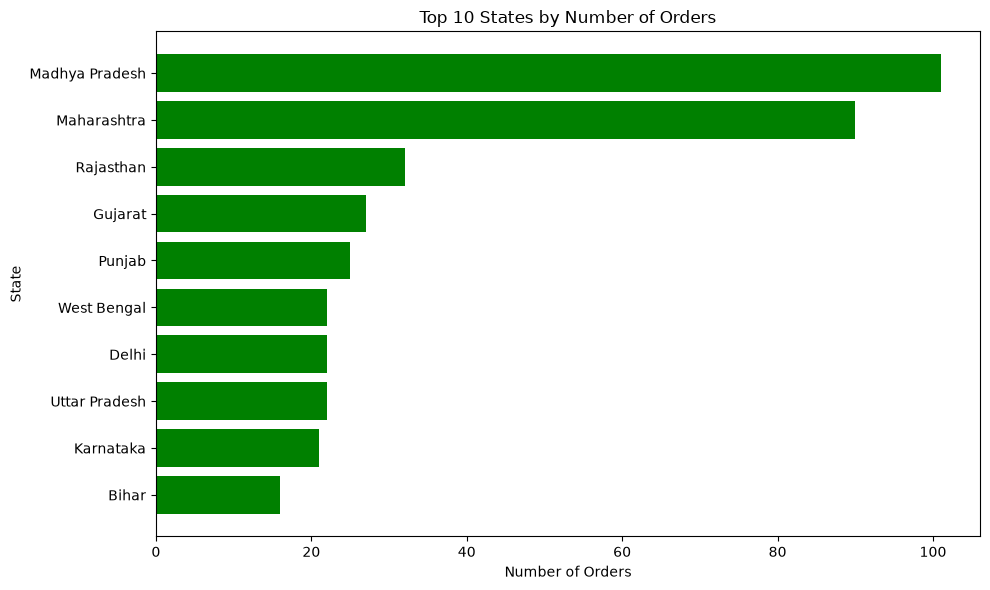

In [20]:
#TOP 10 STATES GRAPH
top_states_graph = top_states.sort_values("Orders")
plt.figure(figsize=(10, 6),)
plt.barh(top_states_graph["State"],top_states_graph["Orders"],color="green")

plt.title("Top 10 States by Number of Orders")
plt.xlabel("Number of Orders")
plt.ylabel("State")

plt.tight_layout()
plt.show()

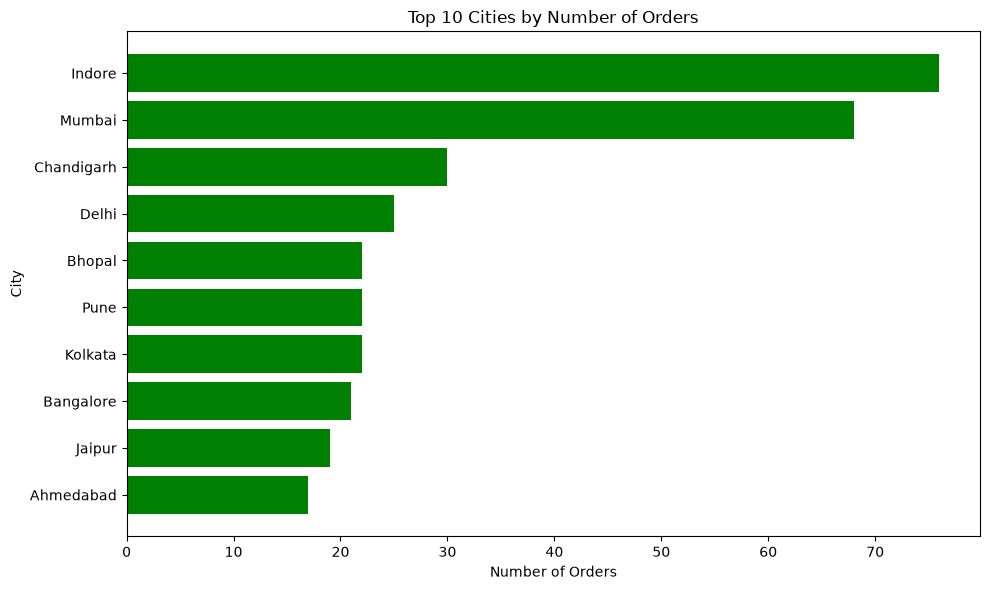

In [21]:
#TOP 10 CITIES GRAPH
top_cities_graph = top_cities.sort_values("Orders")
plt.figure(figsize=(10, 6))

plt.barh(top_cities_graph["City"],top_cities_graph["Orders"],color="green")

plt.title("Top 10 Cities by Number of Orders")
plt.xlabel("Number of Orders")
plt.ylabel("City")

plt.tight_layout()
plt.show()

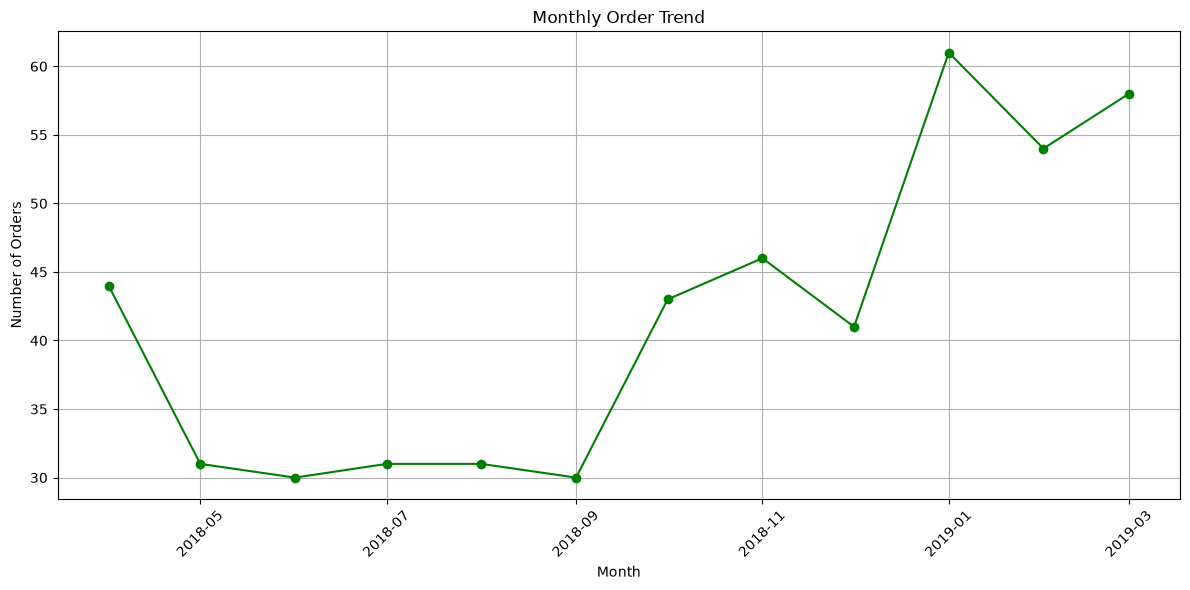

In [22]:
plt.figure(figsize=(12, 6))
plt.plot(monthly_orders["Order Date"],monthly_orders["Orders"],marker="o",color="green")
plt.title("Monthly Order Trend")
plt.xlabel("Month")
plt.ylabel("Number of Orders")
plt.xticks(rotation=45)
plt.grid(True)

plt.tight_layout()
plt.show()

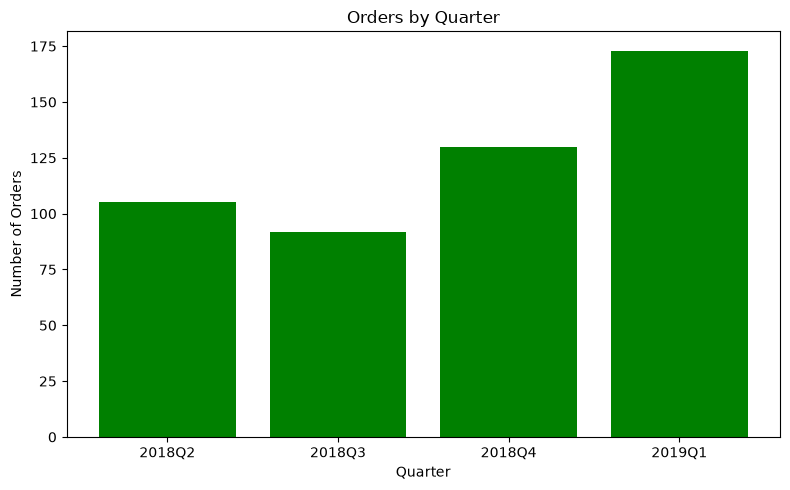

In [23]:
plt.figure(figsize=(8, 5))
plt.bar(quarter_orders["Quarter"],quarter_orders["Orders"],color="green")
plt.title("Orders by Quarter")
plt.xlabel("Quarter")
plt.ylabel("Number of Orders")

plt.tight_layout()
plt.show()

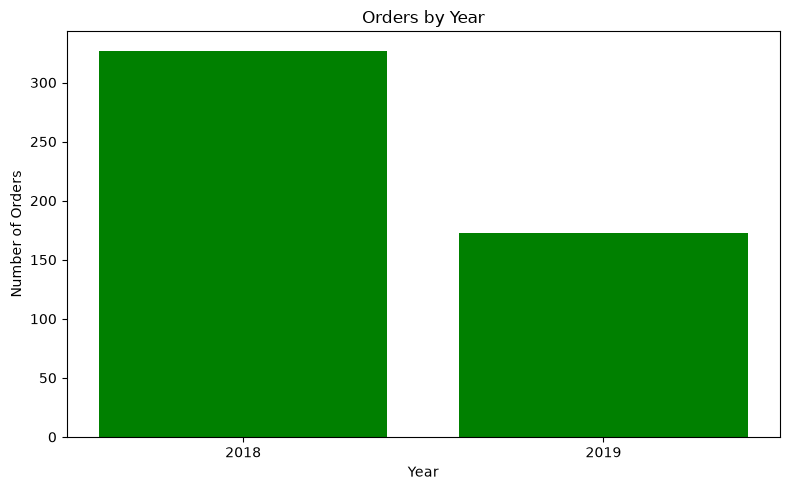

In [24]:
plt.figure(figsize=(8, 5))
plt.bar(year_orders["Year"].astype(str),year_orders["Orders"],color="green")

plt.title("Orders by Year")
plt.xlabel("Year")
plt.ylabel("Number of Orders")
plt.tight_layout()
plt.show()

In [28]:
#SAVE THE RESULT
df.to_csv("cleaned_list_Of_orders.csv", index=False)

In [29]:
DF = pd.read_csv("cleaned_list_Of_orders.csv")
DF

,Order ID,Order Date,CustomerName,State,City,Year,Month,Month Name,Quarter
0,B-25601,2018-04-01,Bharat,Gujarat,Ahmedabad,2018,4,April,2018Q2
1,B-25602,2018-04-01,Pearl,Maharashtra,Pune,2018,4,April,2018Q2
2,B-25603,2018-04-03,Jahan,Madhya Pradesh,Bhopal,2018,4,April,2018Q2
3,B-25604,2018-04-03,Divsha,Rajasthan,Jaipur,2018,4,April,2018Q2
4,B-25605,2018-04-05,Kasheen,West Bengal,Kolkata,2018,4,April,2018Q2
...,...,...,...,...,...,...,...,...,...
495,B-26096,2019-03-28,Atharv,West Bengal,Kolkata,2019,3,March,2019Q1
496,B-26097,2019-03-28,Vini,Karnataka,Bangalore,2019,3,March,2019Q1
497,B-26098,2019-03-29,Pinky,Jammu and Kashmir,Kashmir,2019,3,March,2019Q1
498,B-26099,2019-03-30,Bhishm,Maharashtra,Mumbai,2019,3,March,2019Q1
